# Analysis of MS Progression based on Brain Lesion and clinical Disease Progression Measurements  

In this notebook we present a simulated analysis of Multiple Sclerosis disease progression using both image and clinical data. The analysis consits of three parts: An image segmentation, where the brain lesion is detected, a federated statistical analysis, how the brain lesion relates to other clinical measurements and finally a time-dependent analysis of the progression of the disease symptoms. 

## Three-Part Analysis:

### 1. Image Segmentation
For the image analysis we first fine-tune an nnU-Net model in a federated learning setting and then use the fine-tuned model for inference on a public MRI dataset.

### 2. Federated Statistical Analysis

Next, we examine the remaining clinical data to gain deeper insights into the statistical patterns and the relationships between brain lesions and other patient characteristics. For this purpose, we examine both the individual datasets and their combined statistical population within a federated analysis.

### 3. Time-Dependent Federated Analysis

Finally, we investigate the temporal progression and assess the risk of developing at least a minimal degree of measurable disability — both for the overall population and for the individual patient.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from IPython.display import clear_output
import time
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import warnings

import apheris
from aphcli.api import (
    job,
    compute,
    models
)
from apheris_preprocessing import FederatedDataFrame
from apheris_stats.simple_stats import (
    pca_transformation,
    cov,
    tableone,
    corr,
    histogram,
    describe,
    kaplan_meier,
    mean_column,
    count_group_by,
    median_with_confidence_intervals_column,
    median_with_quartiles
)
from apheris_stats.simple_stats.util import SimpleStatsSession, LocalDebugSimpleStatsSession
from regression.cox.api_client import fit_coxph
from regression.session import SupervisedMLSession, LocalDebugMLSession
from apheris_utils.user_api_helpers.dataset_utils import LocalDebugDataset

dataset_path = "img_data"

sns.set_theme(font_scale=2)  


In [3]:
# preprocessing functions

def add_one_hot(fdf, col, categories):
    for cat in set(categories):
        fdf[cat] = fdf[col].str.contains(cat)
    return fdf

def prepare_dates(federated_df):
    for col in ["VISITDT", "DIAGDT", "DTFSTSYM", "TRTSDTC"]:
        federated_df[col] = federated_df[col].to_datetime()


    federated_df["VISDTYR"] = federated_df["VISITDT"].dt.year
    federated_df["DAYS_DIAG"] = (
        federated_df["VISITDT"] - federated_df["DIAGDT"]
    ).astype("timedelta64[ns]").dt.days
    
    return federated_df

def get_survival(federated_df):

    federated_df["EVENT"] = federated_df["EDSS"] > 2
    return federated_df

def discretize(fdf, col, buckets):
    fdf[f"{col}_bucket"] = 0
    for b in buckets:
        mask = (fdf[col] > b)
        fdf.loc[mask, f"{col}_bucket"] = b
    return fdf


# plotting functions
def get_box_data(boxplot_df, indices):
    box_data = []
    for idx in indices:
        box_data.append({
            'label': idx,
            'med': boxplot_df.loc[idx, "median"],
            'q1':  boxplot_df.loc[idx, "quartile_1"],
            'q3': boxplot_df.loc[idx, "quartile_3"],
            'whislo':  boxplot_df.loc[idx, "min"],   
            'whishi':  boxplot_df.loc[idx, "max"],   
        })
    return box_data

warnings.filterwarnings('ignore')

In [4]:
apheris.login()

You are already logged in


# 1. Image Analysis: Detect Brain Lesion on MRI Scans (nnU-Net)

For the image analysis we use the `apheris-nnunet` model from `Apheris` model registry.
nnU-Net is an open-source model for biomedical image segmentation, based on the [2020 paper by Isensee et. al.](https://www.nature.com/articles/s41592-020-01008-z). It is designed to configure itself for various datasets without manual intervention. By optimizing its entire pipeline for each new dataset, including preprocessing, network architecture, training, and post-processing, nnU-Net aims to address the complexities of creating deep learning models for medical image analysis.

## A. Preparatory Task: Fine-tune nnU-Net model for brain lesion segmentation

We fine-tune `apheris-nnunet` on the medical imaging dataset from [Guarnera et. al.](https://springernature.figshare.com/articles/dataset/MSLesSeg_baseline_and_benchmarking_of_a_new_Multiple_Sclerosis_Lesion_Segmentation_dataset/27919209). 
This dataset was divided into two parts, and the training splits of both federated datasets were used for fine-tuning. The resulting checkpoint is subsequently used for inference.

## Training Data

The dataset contains 115 NIFTI brain MRI scans from 75 patients, with three channels: T1, T2, and FLAIR. Each scan has 182 slices and an associated segmentation mask marking expert-annotated brain lesions for every slice. The 115 scans are split by patient ID into two subsets of 50 and 65 images.
Both datasets were further split into train and test such that we end up with 41 train and 9 test images on site-1 and 52 train and 13 test images on site-2.

<figure>
    <img src="figures/MSLesSeg_Dataset.png" alt="Brain Lesion Dataset" width="1300">
    <figcaption> MS induced Brain Lesion <a href= https://springernature.figshare.com/articles/dataset/MSLesSeg_baseline_and_benchmarking_of_a_new_Multiple_Sclerosis_Lesion_Segmentation_dataset/27919209> Dataset </a>,
        which contains 115 labeled MRI Scans as nifti images.</figcaption>
</figure>






## B. Run inference on test split to detect brain lesion

An inference job will produce for each image in the inference set an inferred segmentation mask per each slice of the MRI scan.
To run an inference job we need at first to create a "Compute Spec", which is a specialized contract that encapsulates the execution environment and parameters for securely running statistics functions and machine learning models on specified datasets. Think of it as a blueprint that includes:

 - **Dataset ID(s):** Each Compute Spec is linked to a specific dataset or datasets by an identifier. This ID is used to identify which Gateways the code runs on
 - **Model:** This is defined through a Docker image that contains the pre-configured environment in which the code will execute. It ensures consistency and reproducibility by packaging the code, runtime, system tools, system libraries, and settings.
 - **Max Compute resources:** Here, the Compute Spec details the required computing resources; specifically the type and number of virtual CPUs, the amount of RAM, and any GPU requirements. This ensures that the computation will run on infrastructure that's equipped to handle the task's demands.


To make the checkpoint available on the Gateway, register it as dataset or use Apheris artifact store. Below is an example of a compute specification that can be used to run inference jobs with an nnU-Net model initialized from the checkpoint `mslesseg-checkpoint_gateway-2_org-2` generated during the previous training run.

```
dataset_ids = ["mslesseg-mri_gateway-2_org-2", "mslesseg-checkpoint_gateway-2_org-2"]

compute_spec_id_nnunet = compute.create_from_args(
    dataset_ids=dataset_ids,
    model_id='apheris-nnunet',
    model_version="0.26.0",
    client_memory=32000,
    client_n_cpu=14,
    client_n_gpu=1,
    server_memory=16000,
    server_n_cpu=7,
    server_n_gpu=0,
)


compute.activate(compute_spec_id_nnunet)
compute.wait_until_running(compute_spec_id_nnunet)
compute.get_status(compute_spec_id_nnunet)
```

Once the compute specification is activated, it is ready to accept submitted jobs.
To submit an inference job, you must first define a payload that specifies which workflow to run on the model and the required job arguments.

```
payload = {
    "mode": "inference",
    "device": "cuda",
    "fold_id": "all",
    "checkpoint_dataset_id": "mslesseg-checkpoint_gateway-2_org-2",
    "apheris_dataset_subdirs": {"mslesseg-mri_gateway-2_org-2": "imagesTs"}
}

job.submit( payload,
    compute_spec_id=compute_spec_id, verbose=True
)
```

## C. Inference Results

The inference results are generated in the same format as the training data labels. Whether they can be returned to the user or stored on the Gateway for further use in downstream tasks depends on the specific model implementation and privacy requirements. In some cases, an inferred segmentation mask at the individual patient level may already be considered disclosive, and only aggregated measures, such as brain lesion volume, can be derived and used to enrich the clinical dataset.

In the current implementation, however, full segmentation masks are returned.

### Data Privacy and Access

Note that the raw data always remains on the Gateway and is never returned. This applies for the image data channels as well as for the ground truth labels.


```
if job.status() == 'finished.completed':
    job.download_results("/tmp/MSLesSeg_Dataset_Inference")
```    

## D. Illustration of Inference Results on a locally available Test Datapoint

In the cell below, each frame shows a single slice of an image data point (bottom row) alongside the corresponding true and predicted segmentation masks (top row). For illustration purposes, we stop at slice 67. The Dice score for the selected slice is 0.85, while the overall image score is 0.67. In the bottom row, MRI images from the FLAIR, T1, and T2 channels are displayed.

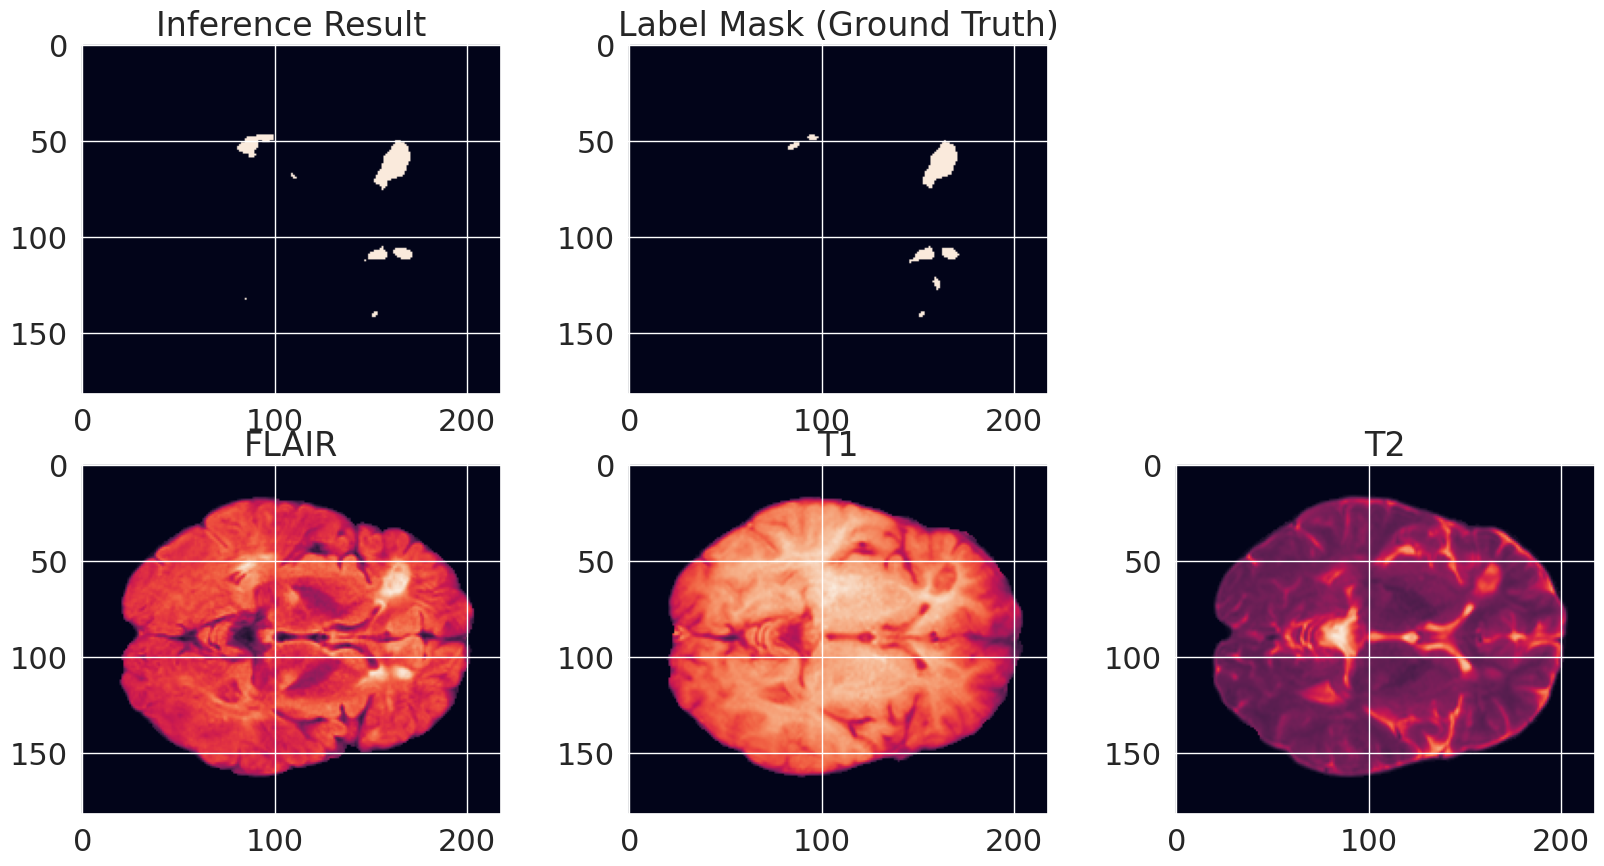

In [5]:
i=67
j=1

img0_load = nib.load(f"{dataset_path}/T{j}_00{i}.nii.gz").get_fdata()
img1_load = nib.load(f"{dataset_path}/P{i}_FLAIR.nii.gz").get_fdata()
img2_load = nib.load(f"{dataset_path}/P{i}_T1.nii.gz").get_fdata()
img3_load = nib.load(f"{dataset_path}/P{i}_T2.nii.gz").get_fdata()
img4_load = nib.load(f"{dataset_path}/P{i}_MASK.nii.gz").get_fdata()
for i in range(50,img1_load.shape[2]):
    clear_output(wait=True)   # clear previous plot    plt.imshow(img_load[:,:,20])
    fig = plt.figure(figsize = (20,10))
    fig0 = fig.add_subplot(2, 3, 1, title = "Inference Result")
    fig1 = fig.add_subplot(2, 3, 4, title = "FLAIR")
    fig2 = fig.add_subplot(2, 3, 5, title = "T1")
    fig3 = fig.add_subplot(2, 3, 6, title = "T2")
    fig4= fig.add_subplot(2, 3, 2, title = "Label Mask (Ground Truth)")

    fig0.imshow(img0_load[:,:,i])
    fig1.imshow(img1_load[:,:,i])
    fig2.imshow(img2_load[:,:,i])
    fig3.imshow(img3_load[:,:,i])
    fig4.imshow(img4_load[:,:,i])
    plt.show()
    time.sleep(0.3)
    if img4_load[:,:,i].sum() > 350:
        break


#### Remark: Depending on the use case and dataset, even inferred lesion segmentations can be disclosive. In such cases, the model can be adjusted to return only aggregated predictions, such as lesion volume, instead of complete label masks.

# 2. Examine Brain Lesion Volume in Relation to MS Progression

One piece of information derived from the inferred segmentation mask is the brain lesion volume. We assume this information is available in our 
clinical data tables and explore the relation to other clinical measurements.

## Statistical analysis on clinical data

Now we explore the clinical data from two different sites - first analyzing each site individually, and then comparing these single-site results with the outcomes of the combined statistical ensemble to see whether the ensemble provides deeper insights than the individual analyses.

For this purpose, we define a compute spec again, this time for statistical computations based on `apheris-statistics`.

In [6]:
compute_spec_id = None

In [7]:
dataset_ids = ["ms-synth-clinical-data_gateway-1_org-1", "ms-synth-clinical-data_gateway-2_org-2"]

if compute_spec_id is None:
    compute_spec_id = compute.create_from_args(
        dataset_ids=dataset_ids, 
        model_id="apheris-statistics", model_version="0.48.0",
        client_n_cpu=1, 
        client_memory=1000,
        client_n_gpu=0, 
        server_n_cpu=1, 
        server_n_gpu=0, 
        server_memory=1000
    )
compute.activate(compute_spec_id=compute_spec_id)
compute.wait_until_running(compute_spec_id)
session = SimpleStatsSession(compute_spec_id)

compute.get_status(compute_spec_id)

{'status': 'running',
 'message': '{"5a873d08-7f58-4a5f-953c-87a1b7726a0b":"The computation has been scheduled","f44f2052-659a-43fd-84f8-8942627d222c":"The computation has been scheduled","orchestrator":"The computation has been scheduled"}',
 'details': '{"5a873d08-7f58-4a5f-953c-87a1b7726a0b":"The computation is running.","f44f2052-659a-43fd-84f8-8942627d222c":"The computation is running.","orchestrator":"The computation is running."}'}

We also define preprocessing wrapper classes `FederatedDataFrame` around each dataset id and use it later to define preprocessing operations on the remote data.

In [8]:
fdf_1 = FederatedDataFrame("ms-synth-clinical-data_gateway-1_org-1")
fdf_2 = FederatedDataFrame("ms-synth-clinical-data_gateway-2_org-2")

In [9]:
datasets = [fdf_1, fdf_2]

In [10]:
numerical_columns = [
 'CNSR',
 'CHG',
 '9HPT',
 'EDSS',
 'T25FWT',
 'SDMT',
 'MSFC',
 'RELAPSE',
 'CDA',
 'LESION_VOLUME'
]

for col in numerical_columns:
    for fdf in datasets:
        fdf[col] = fdf[col].fillna(0)


## Federated Exploratory Data Analysis (EDA)


We begin with a simple exploratory data analysis, starting with a \texttt{tableone} computation that provides descriptive statistics for a 
selection of numerical columns. The result is shown in the resulting table of the `tableone` computation.


In [11]:
sns.reset_defaults()

res_tab_one = tableone(numerical_columns=numerical_columns, 
         numerical_nonnormal_columns=numerical_columns, 
         datasets=datasets, session=session)
res_tab_one

Output()

Computation submitted under Job ID: 41bbbfec-8902-44dd-9e30-414ae6486c3e

,col,category,n,mean,std,min,quartile_1,median,quartile_3,max
0,MSFC,total,1386,-2.327558,2.023381,-9.328131,-3.717779,-2.315191,-1.068446,6.256180
1,LESION_VOLUME,total,1386,2188.318170,2136.344098,0.549024,414.032522,1034.257769,3721.900505,10337.636473
2,CHG,total,1386,0.388434,0.308890,-0.484591,0.175954,0.383554,0.591154,1.402680
3,EDSS,total,1386,3.511068,2.161395,0.030000,1.710000,2.970000,4.930000,14.030000
4,9HPT,total,1386,22.656566,9.772688,0.000000,15.960000,21.660000,28.500000,57.000000
5,SDMT,total,1386,55.564935,10.148488,27.000000,48.600000,54.600000,63.000000,87.000000
6,CDA,total,1386,0.043290,0.203509,0.000000,0.010000,0.010000,0.010000,1.000000
7,CNSR,total,1386,0.011544,0.106821,0.000000,0.010000,0.010000,0.010000,1.000000
8,T25FWT,total,1386,8.911255,2.532912,2.000000,6.960000,8.880000,10.960000,18.000000
9,RELAPSE,total,1386,3.112554,1.824248,0.000000,1.980000,2.970000,3.960000,9.000000


The resulting table is visualized as a boxplot below with median, quartiles and range.

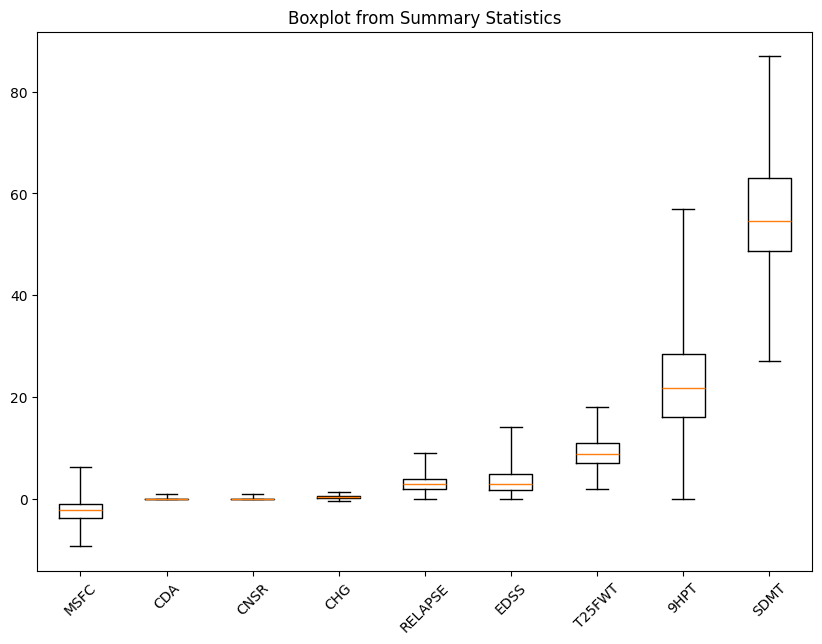

In [12]:
boxplot_df = res_tab_one.set_index("col")[["min", "quartile_1", "median", "quartile_3", "max"]]
boxplot_df = boxplot_df.sort_values(by="median")

fig, ax = plt.subplots(figsize=(10,7))
plt.title("Boxplot from Summary Statistics")

box_data = get_box_data(boxplot_df, list( boxplot_df.index[:-1]))     
    
ax.bxp(box_data, showfliers=False)
xl = ax.get_xticklabels()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()


## Federated vs Separate Remote Computation

To identify potential differences in the data distribution, we apply the `tableone` function to each federated dataset separately and compare the resulting boxplots.

*Note: If privacy enhancing methods are configured for a site, they are applied independently from how many sites are taken into investigation.*

In [13]:
res_tab_one1 = tableone(numerical_columns=numerical_columns, 
         numerical_nonnormal_columns=numerical_columns, 
         datasets=[fdf_1], session=session)

res_tab_one2 = tableone(numerical_columns=numerical_columns, 
         numerical_nonnormal_columns=numerical_columns, 
         datasets=[fdf_2], session=session)

Output()

Computation submitted under Job ID: 573855e0-1733-49cc-a5e4-e740174fb8b5

Output()

Computation submitted under Job ID: 83033c7e-1bf4-4314-8ae4-73981b64b298

### EDA on each individual site

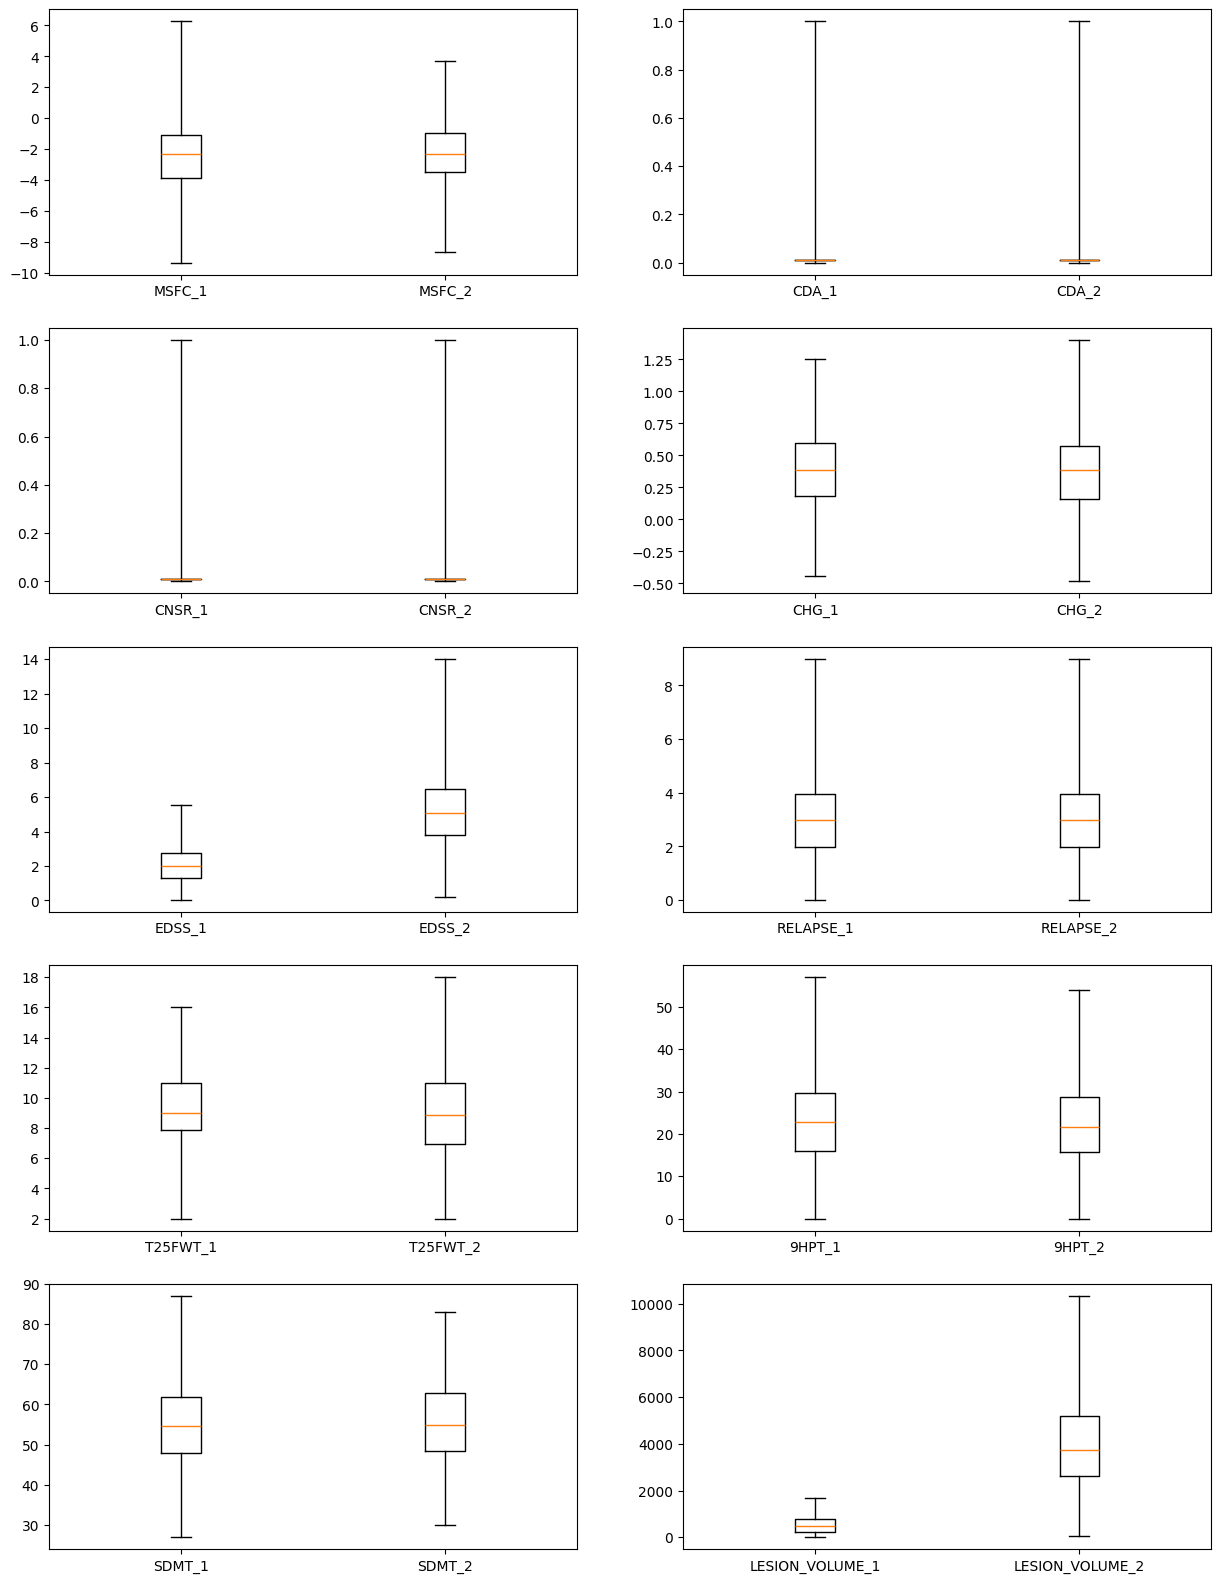

In [14]:
boxplot_df1 = res_tab_one1.set_index("col")[["min", "quartile_1", "median", "quartile_3", "max"]]
boxplot_df1 = boxplot_df1.sort_values(by="median")
boxplot_df2 = res_tab_one2.set_index("col")[["min", "quartile_1", "median", "quartile_3", "max"]]
boxplot_df2 = boxplot_df2.sort_values(by="median")
boxplot_df = boxplot_df2.T.join(boxplot_df1.T, rsuffix = "_1", lsuffix = "_2").T
indices = list(boxplot_df1.index)

fig = plt.figure(figsize = (15,20))
for i, idx in enumerate(indices):
    axtop = fig.add_subplot(5, 2, i+1)
    box_data = get_box_data(boxplot_df, [f"{idx}_1", f"{idx}_2"])        
    axtop.bxp(box_data, showfliers=False)
    xl = axtop.get_xticklabels()
    axtop.set_xticklabels(axtop.get_xticklabels(), rotation=0)
plt.show()

### Compare correlation per site 

Having observed differences in some key variables, we now turn our attention to the correlations between them. We compute a correlation matrix first for each individual dataset and then for the combined dataset.

In [15]:
res1 = corr(column_names=list(numerical_columns) , datasets=[fdf_1], session=session)
res2 = corr(column_names=list(numerical_columns) , datasets=[fdf_2], session=session)

Output()

Computation submitted under Job ID: eb466099-54db-4e52-8645-011cbb419541

Output()

Computation submitted under Job ID: 142e3f86-b0f4-4a8a-a417-92510d8cbfca

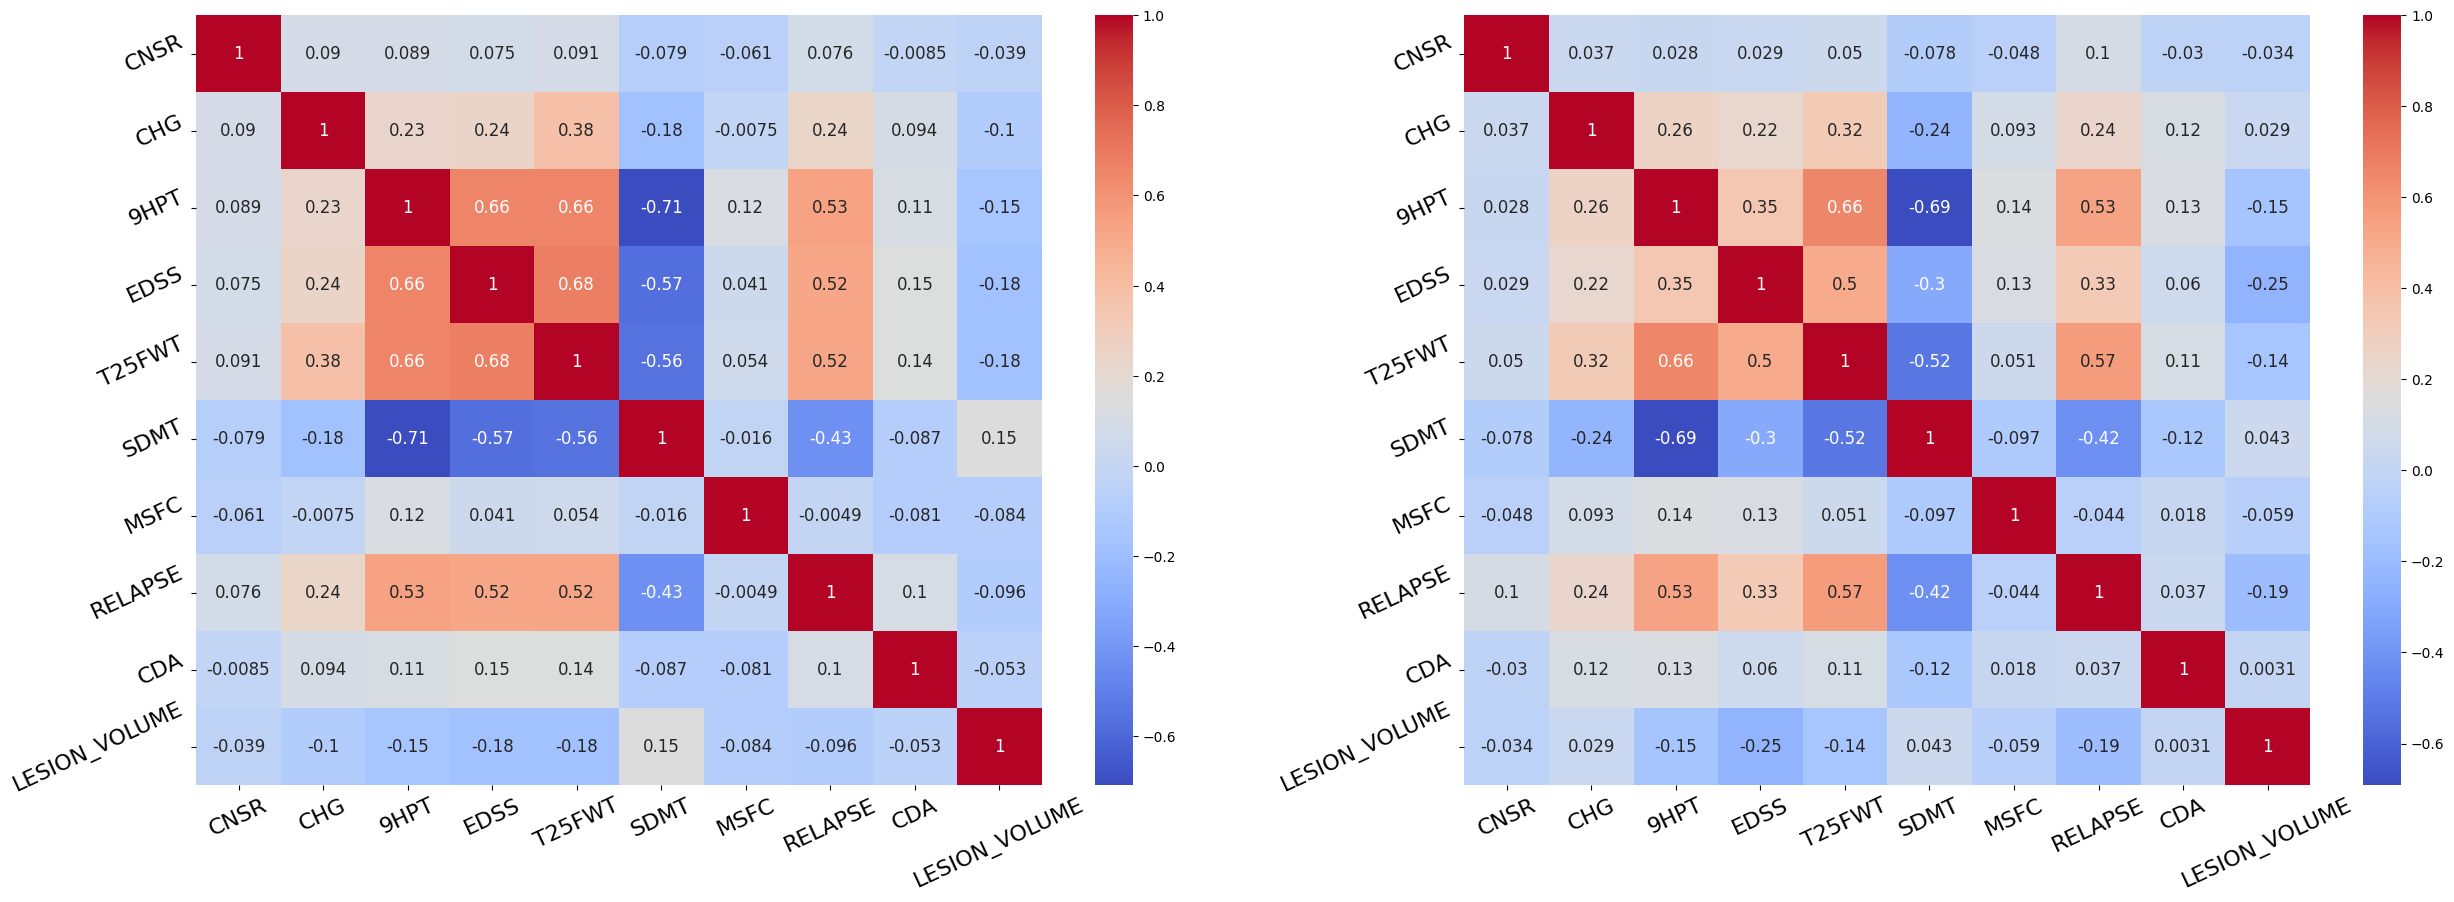

In [16]:
fig = plt.figure(figsize=(30,10))

fig0 = fig.add_subplot(1, 2, 1)
fig1 = fig.add_subplot(1, 2, 2)

sns.heatmap(res1.loc['total'], ax=fig0, annot=True, cmap="coolwarm", annot_kws={"size": 12})
sns.heatmap(res2.loc['total'], ax=fig1, annot=True, cmap="coolwarm", annot_kws={"size": 12})

fig0.set_xticklabels(fig0.get_xticklabels(), fontsize=16,  rotation=25)
fig0.set_yticklabels(fig0.get_xticklabels(), fontsize=16,  rotation=25)
fig1.set_xticklabels(fig1.get_yticklabels(), fontsize=16,  rotation=25)
fig1.set_yticklabels(fig1.get_yticklabels(), fontsize=16,  rotation=25)
plt.show()

The correlation matrix shows a stronger correlation between functional outcome measures on site 1 and some punctual differences in lesion volume and relapse.

<img src="figures/heatmap-sites.png" alt="Correlation per Site">

# Federated Correlation and Scatter Plot

Interestingly, when we look at the federated correlation matrix, the result is unexpected: the negative correlation between EDSS and brain lesion volume that appeared in the separate analyses seems to have flipped.

In [17]:
res = corr(column_names=numerical_columns , datasets=datasets, session=session)

Output()

Computation submitted under Job ID: f0de1b82-d31a-4c80-8543-62d20a2d9fe8

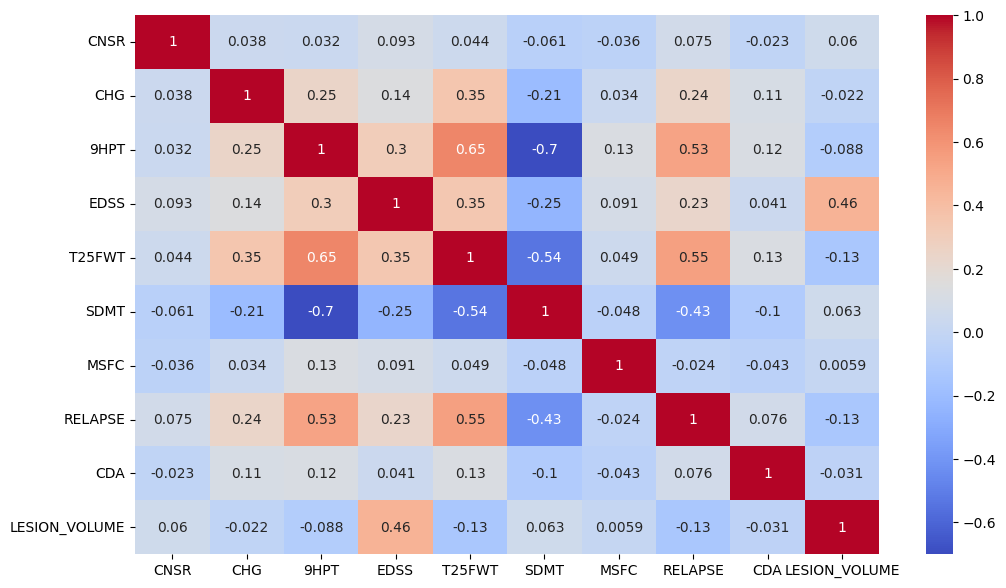

In [18]:
plt.figure(figsize=(12,7))
sns.heatmap(res.loc['total'], annot=True, cmap="coolwarm")
plt.show()

<img src="figures/heatmap.png" alt="correlation switch" width="800" height="800">

## Detailed Exploration and Visualization

To better understand what is happening here, without directly accessing the data, we use a privacy-preserving discretization and visualize the results in a scatter plot. The visualization immediately reveals an example of Simpson’s Paradox, where correlations within individual subsets reverse when the data are combined.

In [19]:

discretizations = {
    "LESION_VOLUME": list(range(0,8000,500)), 
    "EDSS": list(np.arange(0, 10, 0.5)),
}

discretized_datasets = []
for fdf in datasets:
    for col, buckets in discretizations.items():
        fdf = discretize(fdf, col, buckets)
    discretized_datasets.append(fdf)

In [20]:
boxed_count = count_group_by(datasets=datasets, session=session, column_name=["LESION_VOLUME_bucket", "EDSS_bucket"]) 
boxed_count_1 = count_group_by(datasets=[fdf_1], session=session, column_name=["LESION_VOLUME_bucket", "EDSS_bucket"]) 

Output()

Computation submitted under Job ID: a6fab9a2-4415-4469-b9e1-fae34a15a50f

Output()

Computation submitted under Job ID: 23c9c5fe-7df2-44ca-8f20-792cf5b093b7

<Figure size 640x480 with 0 Axes>

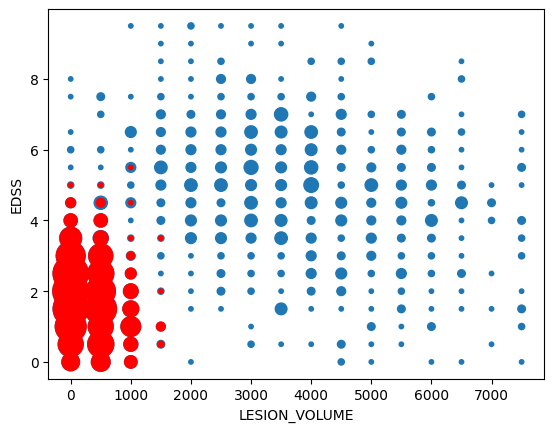

In [21]:
df = boxed_count.drop("total").droplevel([2,3]).reset_index(names = ["LESION_VOLUME", "EDSS"])
df1 = boxed_count_1.drop("total").droplevel([2,3]).reset_index(names = ["LESION_VOLUME", "EDSS"])

plt.figure()
ax = df.plot.scatter(x="LESION_VOLUME", y="EDSS", s=df["count"]*10)
df1.plot.scatter(x="LESION_VOLUME", y="EDSS", s=df1["count"]*10, c="red", ax=ax)
plt.show()


<img src="figures/correlations2.png" alt="LESION_VOLUME-EDSS Correlation" width="500" height="400">

# 3. Time Dependent Analysis of MS Progression - Longitudinal and Survival Analysis

We have already learned a great deal about the static characteristics of the current dataset. To describe disease progression, we now aim to better understand its evolution over time.

To this end, we first convert the date columns into datetime objects using `apheris-preprocessing`. This enables the computation of time differences and the harmonization of temporal variables.


In [22]:
dt_columns = ["VISITDT", "DIAGDT", "DTFSTSYM", "TRTSDTC"]
datasets_with_dates = [prepare_dates(fdf) for fdf in datasets]

datasets_with_timestamps = [fdf.loc[:, dt_columns].fillna(0).astype(int) for fdf in datasets_with_dates]

eda_dates = tableone(numerical_nonnormal_columns=dt_columns,
                     session=session, datasets= datasets_with_timestamps)


eda_dates.loc[:,['min', 'quartile_1', 'median', 'quartile_3', 'max']] = eda_dates[
    ['min', 'quartile_1', 'median', 'quartile_3', 'max']].apply(pd.to_datetime)
eda_dates

Output()

Computation submitted under Job ID: 9bc62f1f-0ab9-467b-bbdb-22cb673ca813

,col,category,min,quartile_1,median,quartile_3,max,n
0,TRTSDTC,total,2022-03-02,2022-09-16 17:16:48,2023-02-25 15:21:36,2023-09-05 00:00:00,2024-03-07,1386
1,DIAGDT,total,2022-02-01,2022-08-17 15:21:36,2023-02-02 00:00:00,2023-08-04 00:00:00,2024-02-03,1386
2,VISITDT,total,2022-02-26,2022-12-17 22:19:12,2023-06-08 19:40:48,2023-12-08 21:07:12,2024-12-09,1386
3,DTFSTSYM,total,2022-01-02,2022-07-17 13:26:24,2023-01-01 00:00:00,2023-07-09 06:43:12,2023-12-31,1386


In [23]:
def get_followup_interval(fdf):
    fdf = fdf.sort_values(by = "VISITDT")
    fdf["VISITDT"] = fdf["VISITDT"].astype("int")
    fdf["FOLLUP_INTERVAL"] = fdf.loc[:,["VISITDT", "PID"]].groupby("PID").diff()
    return ( fdf.loc[:,["PID","FOLLUP_INTERVAL"]].groupby("PID").mean()
        .astype("timedelta64[ns]").dt.days )

follup_per_patient = [get_followup_interval(fdf) for fdf in datasets_with_dates]


In [24]:

tableone(numerical_nonnormal_columns=["FOLLUP_INTERVAL"], session=session, datasets=follup_per_patient)

Output()

Computation submitted under Job ID: 2bcb7647-db38-405d-b4a5-ba20f9f00eab

,col,category,min,quartile_1,median,quartile_3,max,n
0,FOLLUP_INTERVAL,total,24,28.92,30.0,30.96,36,200


# Kaplan-Meier Survival Function

With this, we have everything in place to model the progression of MS to moderate disability. We define the clinical event “moderate disability reached” as EDSS > 2, representing the transition from subclinical neurological signs to measurable minimal disability.

This threshold was chosen to maximize the sensitivity of the survival analysis for detecting early disease progression and to ensure a sufficient number of events for correlation with imaging biomarkers, which typically manifest early in the disease course.

Datetime objects allow the calculation of date differences. The days since diagnosis are derived from the difference of Visit Date and Diagnosis Date and then used to compute a Kaplan-Meier survival function. In this instance, we are not analyzing patient mortality, but rather the probability of developing an MS-induced disability, as defined by worsening EDSS. 

The results are shown in the plot below, stratified by MS subtype.

In [25]:
fdf_list_survival = [get_survival(fdf) for fdf in datasets_with_dates]

res1 = kaplan_meier(
    datasets=fdf_list_survival, 
    duration_column_name="DAYS_DIAG", 
    event_column_name="EVENT",
    group_by="MSSUBTP",
    stepsize=30,
    session=session, 
    plot=True
)

Output()

Computation submitted under Job ID: 1d209d4b-0bfa-4045-be55-d0ed2c27cf3b

We obtain as result from `kaplan_meier` computation 
- survival_function $S(t)$: probability for not developing a disability until time t
- cumulative_distribution for event: $1 - S(t) $
- at_risk: number of patients at time $t$, which had no event yet (not dead or censored) 

In [26]:
import copy
res_km = copy.deepcopy(res1)

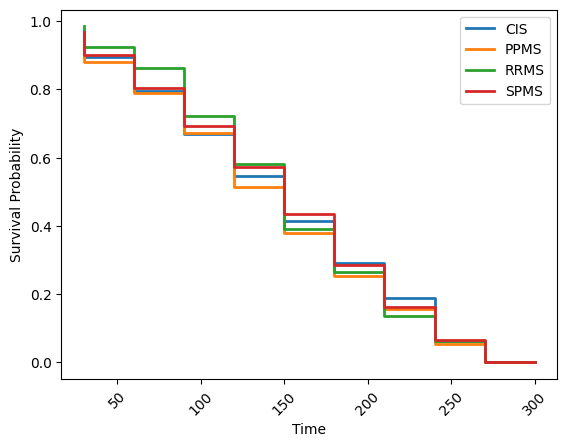

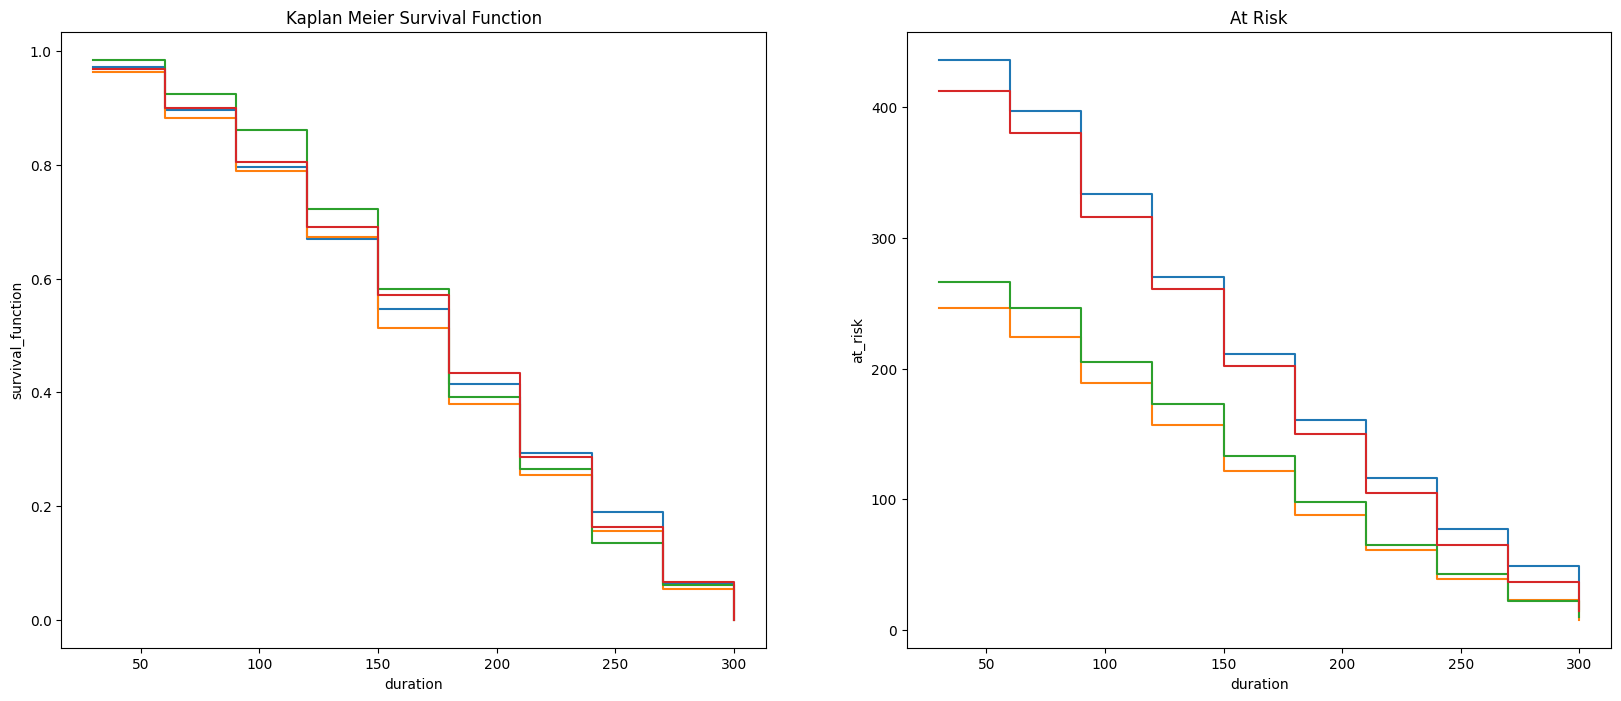

In [27]:
fig = plt.figure(figsize=(20,8))

fig0 = fig.add_subplot(1, 2, 1)
fig1 = fig.add_subplot(1, 2, 2)

for mssubtp,df in res1.items():
    y = df["survival_function"]
    x = df.loc["total"].index.right
    
    sns.lineplot(x=x, y=y, drawstyle='steps-post', ax = fig0)
    fig0.set_xlabel("duration")
    fig0.set_title("Kaplan Meier Survival Function")

for mssubtp,df in res1.items():
    y = df["at_risk"]
    x = df.loc["total"].index.right
    
    sns.lineplot(x=x, y=y, drawstyle='steps-post', ax=fig1)
    fig1.set_xlabel("duration")
    fig1.set_title("At Risk")
plt.show()

## Summary

We now have a solid understanding of correlations, static distributions, and the temporal evolution of MS progression. In the final section of this notebook, we bring these aspects together to model individual disease trajectories.

## Bringing both Strands together: Cox Regression

To model individual disease progression at the patient level, we use a Cox proportional hazards model. This approach models MS progression over time in relation to additional numerical covariates.

We define a new compute spec, this time using `apheris-regression-models`, which contains also a federated implementation of Cox regression.

In [28]:
reg_compute_spec_id = None

In [29]:
if reg_compute_spec_id is None:
    reg_compute_spec_id = compute.create_from_args(
        dataset_ids=dataset_ids, 
        model_id="apheris-regression-models", model_version="0.37.0",
        client_n_cpu=1, 
        client_memory=1000,
        client_n_gpu=0, 
        server_n_cpu=1, 
        server_n_gpu=0, 
        server_memory=1000
    )
compute.activate(compute_spec_id=reg_compute_spec_id)

In [30]:
compute.wait_until_running(reg_compute_spec_id)
cox_session = SupervisedMLSession(reg_compute_spec_id)

In [31]:
selected_numerical_cols = [
 '9HPT',
 'T25FWT',
 'SDMT',
 'MSFC',
 'RELAPSE',
 'LESION_VOLUME'
]

In [32]:
cox_datasets = [fdf.loc[:, selected_numerical_cols + ['DAYS_DIAG', 'EVENT']].fillna(0) for fdf in fdf_list_survival]

cox_model = fit_coxph(
    datasets = cox_datasets, 
    time_col="DAYS_DIAG", 
    target_col="EVENT",
    num_rounds=3,
    max_time=300,
    session=cox_session
)

Computation submitted under Job ID: c1997a72-cb17-49c7-bdd1-060b11b9519e


The result of a Cox regression training job are the model parameters 

 - $\beta$: the regression coefficients and
 - $H_0(t)$: a time discrete baseline hazard function

Taken together, this yields the

**Cox proprotional hazard function:** $H ( t | X) = H_0(t) \cdot exp(\beta X) $

and from this we can derive the

**Survival Function:** $S(t|X) = exp\left(- H(t | X) \right)$.

<Figure size 640x480 with 0 Axes>

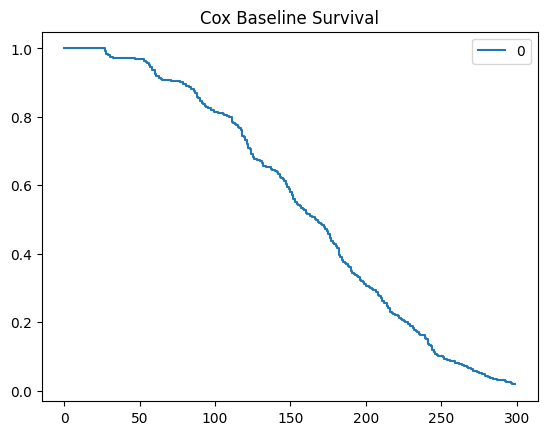

In [33]:
plt.figure()
pd.DataFrame(np.exp(-cox_model['cumulative_hazard'])).plot(title='Cox Baseline Survival', drawstyle = "steps")
plt.show()


The regression coefficients normalized by the average of the respective feature indicates the feature importance.

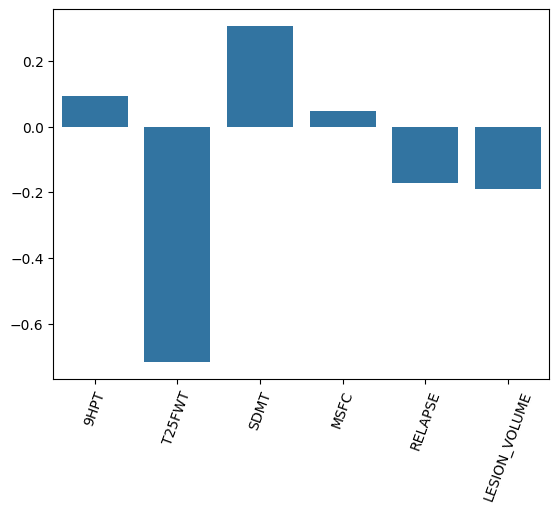

In [34]:
plt.figure()
weights =  res_tab_one.set_index("col")["mean"]
sns.barplot(
    pd.Series(cox_model['coef'], index=selected_numerical_cols)*weights[selected_numerical_cols]
)
plt.xticks(rotation=70)
plt.show()

# Appendix: Categorical Features 

In addition, we extend the modeling approach to incorporate the available categorical features. To obtain a simple vectorized representation, we first apply **one-hot encoding** and then reduce the expanded feature space using **Principal Component Analysis (PCA)**.

## Additional categorical Columns 

In [35]:
categorical_columns = ['VOCSTAT', 'EDUSTAT', 'PRSNTSYM', 'SEX', 'ETHNIC', 'MSSUBTP']
eda_categoricals = tableone(categorical_columns=categorical_columns, session=session, datasets= datasets)
categorical_per_col = eda_categoricals.groupby('col').category.apply(list)
categorical_per_col

Output()

Computation submitted under Job ID: d6f82da3-0fc3-4ba1-80f4-226ee0ac1ff0

col
EDUSTAT            [Primary, Quaternary, Secondary, Tertiary]
ETHNIC                      [African, Asian, Hispanic, White]
MSSUBTP                               [CIS, PPMS, RRMS, SPMS]
PRSNTSYM    [['Fatigue', 'Numbness'], ['Muscle stiffness',...
SEX                                            [Female, Male]
VOCSTAT              [Employed, Retired, Student, Unemployed]
total                                                 [total]
Name: category, dtype: object

### Encode symptoms

To one-hot encode the symptoms, we first split the symptom lists and then encode each individual entry. This can be done using `apheris-preprocessing`; the `add_one_hot` function is defined at the top of this notebook. Encoding the remaining string-valued columns is relatively straightforward.

In [36]:
all_cats = []
col = "PRSNTSYM"
categories = np.concatenate([entry.strip("[]").replace("'","").split(",") for entry in categorical_per_col[col]])
categories = [cat.strip() for cat in categories]
categories = list(np.unique(categories))

for fdf in datasets_with_dates:
    fdf = add_one_hot(fdf, col, categories)    
all_cats += categories
all_cats


['',
 'Difficulty walking',
 'Fatigue',
 'Muscle stiffness',
 'Numbness',
 'Speech problems',
 'Visual disturbances']

### Encode demographics and MS subtype

In [37]:
for col in ['EDUSTAT', 'ETHNIC', 'MSSUBTP', 'SEX', 'VOCSTAT']:
    categories = categorical_per_col[col]
    for fdf in datasets_with_dates:
        fdf = add_one_hot(fdf, col, categories)
    all_cats += categories

all_cats

['',
 'Difficulty walking',
 'Fatigue',
 'Muscle stiffness',
 'Numbness',
 'Speech problems',
 'Visual disturbances',
 'Primary',
 'Quaternary',
 'Secondary',
 'Tertiary',
 'African',
 'Asian',
 'Hispanic',
 'White',
 'CIS',
 'PPMS',
 'RRMS',
 'SPMS',
 'Female',
 'Male',
 'Employed',
 'Retired',
 'Student',
 'Unemployed']

## Dimension Reduction

One-hot encoding results in a high-dimensional feature space. To reduce this to a smaller set of informative dimensions, we perform a federated `pca_transformation`, which ultimately computes a **singular value decomposition (SVD)** of the **federated covariance matrix**.

The resulting transformation matrix can then be applied to the remote datasets using the `transform_columns` function from `apheris-preprocessing`.

In [38]:
one_hot_datasets = [fdf.loc[:, all_cats].fillna(0) for fdf in datasets_with_dates]

transformator = pca_transformation(datasets=one_hot_datasets, session=session,column_names=all_cats, n_components=4)


fdf_transform = [fdf.loc[:, all_cats].transform_columns(transformator) for fdf in one_hot_datasets]



Output()

Computation submitted under Job ID: 76541624-d20c-481e-893a-280a0f8bc6a9

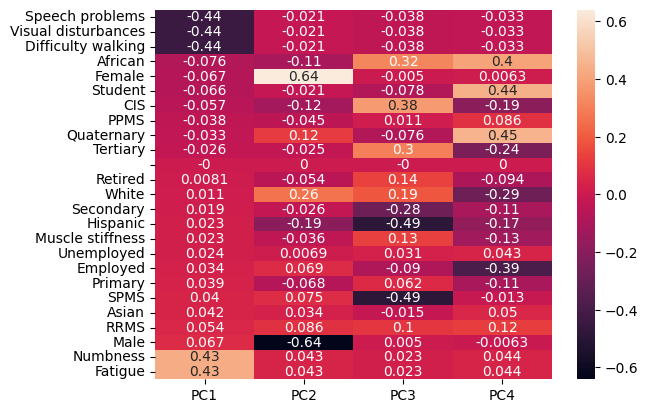

In [39]:
transformator = transformator.sort_values(by=["PC1","PC2"])
sns.heatmap(transformator, annot=True)
plt.show()

### Join transformation with original data

Finally, we join the principal components with the original numerical features and use the extended dataset to fit a Cox regression model.

*Note: The join is performed remotely at each site. Only the transformation matrix is returned to the user; the transformed data itself never leaves the site.*

In [40]:
all_numerical_cols = numerical_columns + list(transformator.columns)

fdf_final = [fdf_t.astype(float).merge(fdf_n, 
                    left_index = True, right_index=True) 
                for fdf_t, fdf_n in zip(fdf_transform, datasets_with_dates)]


res_tab_one = tableone(numerical_columns=all_numerical_cols, 
         numerical_nonnormal_columns = all_numerical_cols, 
         datasets=fdf_final, session=session)



Output()

Computation submitted under Job ID: 3d69b10d-8f0b-4a3b-8c81-76193497a714

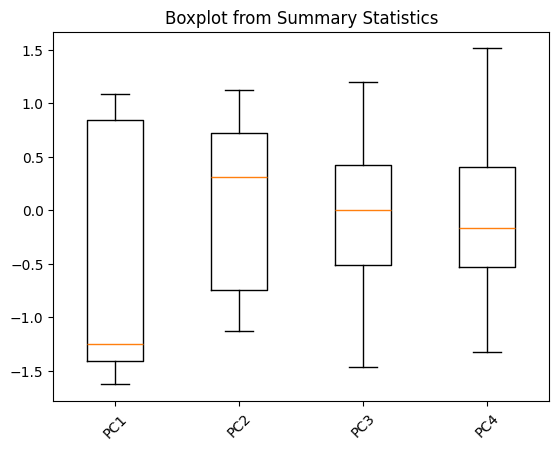

In [41]:
boxplot_df = res_tab_one.set_index("col")[["min", "quartile_1", "median", "quartile_3", "max"]]
fig, ax = plt.subplots()
plt.title("Boxplot from Summary Statistics")

box_data = []
for idx in transformator.columns:

    box_data.append({
        'label': idx,
        'med': boxplot_df.loc[idx, "median"],
        'q1':  boxplot_df.loc[idx, "quartile_1"],
        'q3': boxplot_df.loc[idx, "quartile_3"],
        'whislo':  boxplot_df.loc[idx, "min"],   
        'whishi':  boxplot_df.loc[idx, "max"],   
    })
    
ax.bxp(box_data, showfliers=False)
xl = ax.get_xticklabels()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()


In [42]:
cox_coeffs = selected_numerical_cols + list(transformator.columns)

In [43]:
fdf_cox = [fdf.loc[:, cox_coeffs + ['DAYS_DIAG', 'EVENT']].fillna(0) for fdf in fdf_final]
cox_model = fit_coxph(
    datasets = fdf_cox, 
    time_col="DAYS_DIAG", 
    target_col="EVENT",
    num_rounds=3,
    max_time=2000,
    session=cox_session
)

Computation submitted under Job ID: 3ab8de47-752b-46af-8805-0f1b898598c5


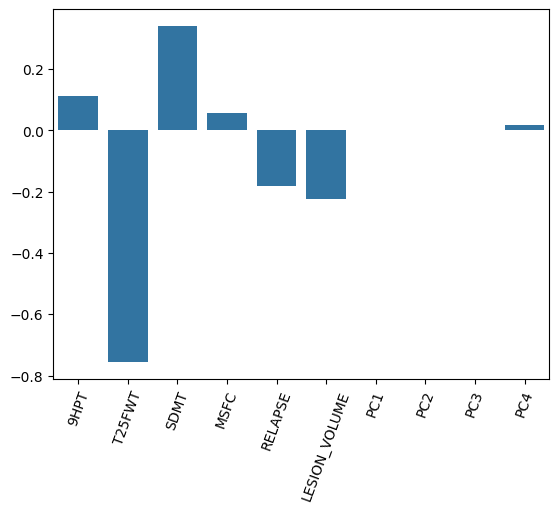

In [44]:
weights =  res_tab_one.set_index("col")["mean"]
sns.barplot(
    pd.Series(cox_model['coef'], index=cox_coeffs)*weights[cox_coeffs]
)
plt.xticks(rotation=70)
plt.show()

In [45]:
compute.deactivate(compute_spec_id)
compute.deactivate(reg_compute_spec_id)